In [1]:
import os
import numpy as np
import math
from PIL import Image, ImageDraw
from IPython.display import display
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
with open("yekui.txt", "r") as f:
    s = f.read()
lines = s.split('\n')
lines.append("99999999999 0 0")

group = []
alldata = []

nowTime = 0

for line in lines:
    if line == "":
        continue
    content = line.split(' ')
    time = int(content[0])
    x = int(content[1])
    y = int(content[2])

    if time - nowTime > 10000 or time < nowTime:
        if group != []:
            alldata.append(group)
        group = []
    
    group.append([time, x, y])
    nowTime = time
    
    

In [3]:
import math
for data in alldata:
    print(data)

[[5171848, 55330, 40756], [5171849, 56370, 43907], [5172149, 54307, 42171], [5172150, 57580, 41889]]
[[5269851, 54761, 41146], [5269851, 56750, 43760], [5270137, 55292, 43814], [5270138, 56640, 40772]]
[[5341846, 56677, 40789], [5342050, 55562, 43907], [5342376, 54363, 41850], [5342683, 57372, 43183]]
[[5376861, 54327, 42009], [5376925, 57625, 42415], [5377184, 56602, 40756], [5377186, 56330, 43916]]
[[5497820, 54880, 43553], [5497939, 57452, 41545], [5498095, 55182, 40826], [5498096, 57545, 42815]]
[[5595829, 56821, 40866], [5596149, 55330, 43830], [5596151, 54849, 41061], [5596420, 57226, 43379]]
[[5667825, 55330, 43830], [5667938, 57503, 41657], [5668148, 54499, 41509], [5668150, 57597, 42617]]
[[5702871, 54335, 41969], [5702966, 56088, 43952], [5703003, 54363, 42736], [5703253, 57142, 41117]]
[[2952826, 54311, 42455], [2952902, 57580, 41889], [2953121, 55844, 40634], [2953121, 57171, 43440]]
[[3050808, 55602, 40670], [3050927, 57627, 42374], [3050929, 54943, 43604], [3051230, 56957

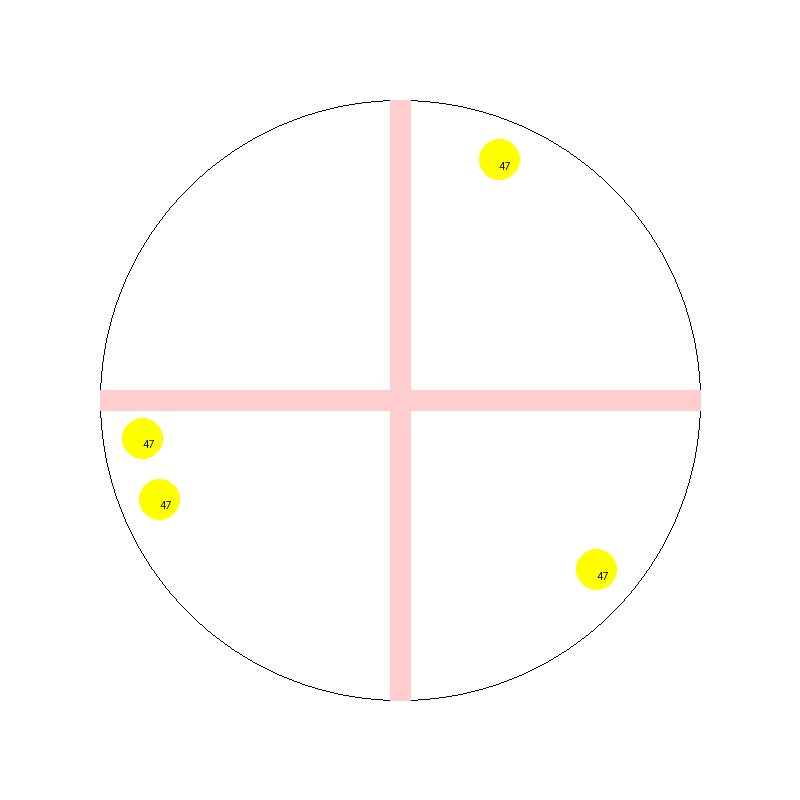

In [4]:
center = [55966,42293]

plotCenter = [400, 400]

def getPos(x, y):
    X = (x - center[0]) / 64 * 10 + plotCenter[0]
    Y = -(y - center[1]) / 64 * 10 + plotCenter[1]
    return X, Y

def getVarPos(x, y, theta, r):
    Theta = theta / 256 * 2 * math.pi
    X = x - r * math.sin(Theta)
    Y = y - r * math.cos(Theta)
    return X, Y

def drawCircle(x, y, r, draw, outline, fill):
    X, Y = getPos(x, y)
    draw.ellipse([X - r, Y - r, X + r, Y + r], outline=outline, fill=fill)
    
def drawCirclePos(x, y, r, draw, outline, fill):
    draw.ellipse([x - r, y - r, x + r, y + r], outline=outline, fill=fill)

def drawText(x, y, text, fill):
    X, Y = getPos(x, y)
    draw.text((X, Y), text, fill=fill)

group = alldata[0]



num = 0
newdata = []

for group in alldata:
    num += 1
    im = Image.new('RGBA', (800, 800), 'white')
    draw = ImageDraw.Draw(im)
    drawCircle(center[0], center[1], 300, draw, 'black', 'white')
    draw.rectangle([(plotCenter[0] - 10, plotCenter[1] - 300), (plotCenter[0] + 10, plotCenter[1] + 300)], fill=(255, 0, 0, 50), outline=None)
    draw.rectangle([(plotCenter[0] - 300, plotCenter[1] - 10), (plotCenter[0] + 300, plotCenter[1] + 10)], fill=(255, 0, 0, 50), outline=None)

    newgroup = []
    for line in group:
        drawCircle(line[1], line[2], 20, draw, None, (255, 255, 0, 255))
        drawText(line[1], line[2], "%d" % num, 'black')
        k = round(math.atan2(line[2] - center[1], line[1] - center[0]) / math.pi * 128 + 128)
        # print(math.atan2(line[2] - center[1], line[1] - center[0]) / math.pi * 128 + 128)
        newgroup.append(k)

    newdata.append(newgroup)
    # im.save("yekui/%d.png" % num)

display(im)




[[48, 182, 3, 118], [31, 172, 209, 81], [82, 202, 11, 151], [7, 131, 80, 183], [221, 109, 44, 141], [86, 208, 34, 157], [208, 112, 20, 136], [8, 189, 245, 96], [252, 118, 61, 159], [55, 130, 219, 90], [3, 162, 91, 207], [58, 172, 236, 131], [83, 196, 238, 153], [4, 151, 87, 199], [215, 115, 51, 162], [253, 152, 76, 194], [36, 160, 227, 125], [236, 144, 27, 196], [3, 120, 44, 225], [253, 112, 79, 204], [3, 144, 62, 187], [41, 177, 3, 131], [20, 144, 204, 107], [42, 153, 239, 91], [96, 197, 22, 140], [233, 94, 54, 148], [90, 192, 20, 129], [80, 183, 21, 150], [220, 82, 18, 150], [234, 112, 16, 179], [71, 165, 248, 132], [234, 120, 73, 197], [11, 162, 237, 93], [234, 154, 70, 175], [17, 120, 76, 181], [217, 139, 53, 140], [21, 120, 241, 77], [63, 193, 18, 143], [66, 183, 13, 124], [233, 59, 17, 139], [77, 191, 33, 115], [241, 136, 57, 174], [7, 136, 72, 169], [10, 160, 95, 195], [16, 115, 212, 65], [227, 84, 18, 178], [16, 176, 6, 99]]
[[3, 48, 74, 118], [31, 47, 81, 84], [11, 54, 82, 105

In [24]:
def roundDistance(x, y, M):
    t = x - y
    if t < 0:
        t += M
    if t > M / 2:
        t = M - t
    return t

for center in [0, 64, 128, 192, 32, 96, 160, 224]:
    for order in [0, 1, 2, 3]:
        distanceData = []
        for data in newdata:
            row = []
            for k in data:
                row.append(roundDistance(k, center, 256))
            row.sort()
            distanceData.append(row)
        A = np.array(distanceData)
        
        print(center, order, A[:, order].mean(), A[:, order].std(), A[:, order].max(), A[:, order].min())


# plt.hist(A[:,0], bins=20)
# plt.show()
# plt.hist(A[:,1], bins=20)
# plt.show()
# plt.hist(A[:,2], bins=20)
# plt.show()
# plt.hist(A[:,3], bins=20)
# plt.show()

0 0 16.680851063829788 10.498442403171607 41 3
0 1 49.808510638297875 16.525464937447992 75 11
0 2 83.04255319148936 13.774718511714058 116 44
0 3 111.65957446808511 10.89656708725311 127 84
64 0 18.02127659574468 11.697407171699037 48 1
64 1 52.40425531914894 13.618916091572055 86 26
64 2 77.59574468085107 13.261140759100797 108 51
64 3 111.0 12.104157892966876 128 79
128 0 16.340425531914892 10.89656708725311 44 1
128 1 44.95744680851064 13.774718511714058 84 12
128 2 78.19148936170212 16.525464937447992 117 53
128 3 111.31914893617021 10.498442403171607 125 87
192 0 17.0 12.104157892966876 49 0
192 1 50.40425531914894 13.261140759100797 77 20
192 2 75.59574468085107 13.618916091572055 102 42
192 3 109.97872340425532 11.697407171699037 127 80
32 0 19.27659574468085 10.777640620618964 50 1
32 1 49.06382978723404 12.960503430134068 80 26
32 2 84.06382978723404 15.206947257986982 113 47
32 3 111.08510638297872 11.768746543343035 128 83
96 0 18.404255319148938 11.726782538308177 48 0
96 

In [36]:
import random
rr = []
for i in range(47):
    r = []
    for j in [0, 64, 128, 192]:
        k = random.randint(j-32, j+32)
        if (k < 0): k += 255
        if (k > 255): k -= 255
        r.append(k)
    rr.append(r)

for center in [0, 64, 128, 192, 32, 96, 160, 224]:
    for order in [0, 1, 2, 3]:
        distanceData = []
        for data in rr:
            row = []
            for k in data:
                row.append(roundDistance(k, center, 256))
            row.sort()
            distanceData.append(row)
        A = np.array(distanceData)
        
        print(center, order, A[:, order].mean(), A[:, order].std(), A[:, order].max(), A[:, order].min())





0 0 14.340425531914894 9.032510067350877 32 0
0 1 55.765957446808514 15.921633571108753 88 32
0 2 76.72340425531915 13.135467866453034 95 36
0 3 108.7872340425532 9.843317573873032 126 96
64 0 16.02127659574468 9.327354786137038 32 0
64 1 50.808510638297875 15.219861460873576 85 32
64 2 75.17021276595744 14.927226515468048 96 35
64 3 113.23404255319149 9.695826621311337 127 96
128 0 19.21276595744681 9.843317573873033 32 2
128 1 51.276595744680854 13.135467866453032 92 33
128 2 72.23404255319149 15.921633571108753 96 40
128 3 113.65957446808511 9.032510067350875 128 96
192 0 14.76595744680851 9.695826621311339 32 1
192 1 52.829787234042556 14.927226515468048 93 32
192 2 77.19148936170212 15.219861460873576 96 43
192 3 111.97872340425532 9.327354786137038 128 96
32 0 24.425531914893618 15.411717952550955 59 0
32 1 42.57446808510638 14.973373077326672 63 8
32 2 84.25531914893617 16.521382772877434 117 64
32 3 107.2127659574468 15.538471364631702 128 68
96 0 18.76595744680851 15.889529224

In [23]:
center = [23443, 19422]

plotCenter = [400, 400]

def getPos(x, y):
    X = (x - center[0]) / 64 * 10 + plotCenter[0]
    Y = -(y - center[1]) / 64 * 10 + plotCenter[1]
    return X, Y

def getVarPos(x, y, theta, r):
    Theta = theta / 256 * 2 * math.pi
    X = x - r * math.sin(Theta)
    Y = y - r * math.cos(Theta)
    return X, Y

def drawCircle(x, y, r, draw, outline, fill):
    X, Y = getPos(x, y)
    draw.ellipse([X - r, Y - r, X + r, Y + r], outline=outline, fill=fill)
    
def drawCirclePos(x, y, r, draw, outline, fill):
    draw.ellipse([x - r, y - r, x + r, y + r], outline=outline, fill=fill)

def drawText(x, y, text, fill):
    X, Y = getPos(x, y)
    draw.text((X, Y), text, fill=fill)

for line in group:
    num += 1
    drawCircle(line[1], line[2], 40, draw, None, (255, 255, 0, 255))
    drawText(line[1], line[2], "%d" % num, 'black')

im = Image.new('RGBA', (800, 800), 'white')
draw = ImageDraw.Draw(im)
drawCircle(center[0], center[1], 250, draw, 'black', 'white')

# draw.rectangle([(plotCenter[0] - 110, plotCenter[1] - 300), (plotCenter[0] + 110, plotCenter[1] + 300)], fill=(255, 0, 0, 50), outline=None)
# draw.rectangle([(plotCenter[0] - 300, plotCenter[1] - 110), (plotCenter[0] + 300, plotCenter[1] + 110)], fill=(255, 0, 0, 50), outline=None)
# draw.rectangle([(plotCenter[0] - 110, plotCenter[1] - 110), (plotCenter[0] + 110, plotCenter[1] + 110)], fill=(255, 0, 0, 100), outline=None)

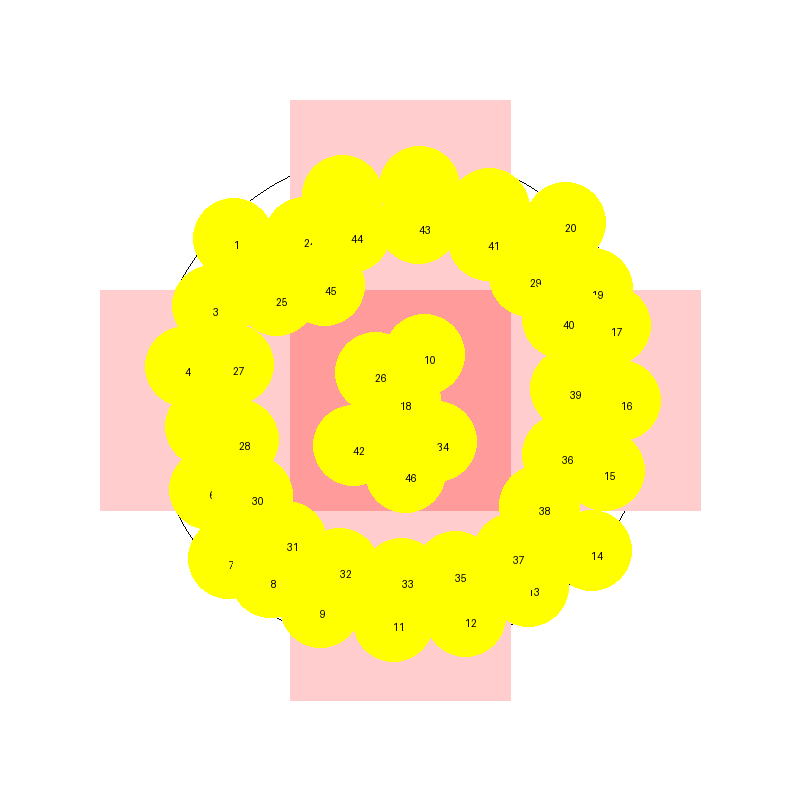

In [36]:



# battle = alldata[7]
# for line in battle:
#     drawCircle(line[1], line[2], 20, draw, 'black', 'red')

baseTime = [70000, 180000, 266000, 395000, 506000, 1000000000]


# def sim(start, final):
#     im = Image.new('RGB', (800, 800), 'white')
#     draw = ImageDraw.Draw(im)

#     drawCircle(center[0], center[1], 200, draw, 'black', 'white')
    
#     n = 0
#     for battle in alldata:
#         n += 1
#         if n != 2:
#             continue
#         start = 0
#         for line in battle:
#             if line[4] < 10000:
#                 # drawCircle(line[1], line[2], 20, draw, 'black', 'red')
#                 if start <= 10:
#                     start = line[0]
#                 X, Y = getPos(line[1], line[2])

# #                 nowBaseTime = 0
# #                 for i in range(5):
# #                     if line[0] > baseTime[i] and line[0] < baseTime[i+1]:
# #                         nowBaseTime = baseTime[i] - 10000
# #                         break
#                 print(line)
#                 print(line[0] - start)
#                 alpha = int(min((line[0] - start) / 9000 * 255, 255))
                        
#                 drawCirclePos(X, Y, 20, draw, 'black', (alpha, alpha, 255))


# #                 for time in range(nowBaseTime + start, nowBaseTime + final, 100):
# #                     r = (time - line[0]) / 1000 * 75
# #                     # print(r)
# #                     x, y = getVarPos(X, Y, line[4], r)
# #                     alpha = int((time - nowBaseTime) / 35000 * 255)
# #                     drawCirclePos(x, y, 20, draw, 'black', (alpha, alpha, 255))

#     drawCircle(center[0], center[1], 20, draw, 'black', 'gray')
#     drawCircle(p1[0], p1[1], 10, draw, 'black', 'blue')
#     drawCircle(p2[0], p2[1], 10, draw, 'black', 'white')
#     drawCircle(p3[0], p3[1], 10, draw, 'black', 'orange')
    
#     drawCircle(p4[0], p4[1], 10, draw, 'black', 'cyan')
#     drawCircle(p5[0], p5[1], 10, draw, 'black', 'cyan')
#     drawCircle(p6[0], p6[1], 10, draw, 'black', 'cyan')

#     display(im)
    
# sim(0, 0)

im = Image.new('RGBA', (800, 800), 'white')
draw = ImageDraw.Draw(im)
drawCircle(center[0], center[1], 250, draw, 'black', 'white')

draw.rectangle([(plotCenter[0] - 110, plotCenter[1] - 300), (plotCenter[0] + 110, plotCenter[1] + 300)], fill=(255, 0, 0, 50), outline=None)
draw.rectangle([(plotCenter[0] - 300, plotCenter[1] - 110), (plotCenter[0] + 300, plotCenter[1] + 110)], fill=(255, 0, 0, 50), outline=None)
draw.rectangle([(plotCenter[0] - 110, plotCenter[1] - 110), (plotCenter[0] + 110, plotCenter[1] + 110)], fill=(255, 0, 0, 100), outline=None)

num = 0
for line in group:
    num += 1
    drawCircle(line[1], line[2], 40, draw, None, (255, 255, 0, 255))
    drawText(line[1], line[2], "%d" % num, 'black')

display(im)



In [26]:
def getAngle(C, X):
    return math.atan2(X[1]-C[1], X[0]-C[0]) / math.pi* 180
    
a1 = getAngle(center, p4)
a2 = getAngle(center, p5)
a3 = getAngle(center, p6)

print(a1)
print(a2)
print(a3)
print(a1-a2)
print(a2-a3)
print(a3-a1)


-14.223530991384088
-103.47255444007111
139.24414815898245
89.24902344868701
-242.71670259905358
153.46767915036654
